In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("../data/food_waste.csv")

# Display first rows
print(df.head())

# Dataset info
print(df.info())

# Statistical summary
print(df.describe())

  Type of Food  Number of Guests Event Type  Quantity of Food  \
0         Meat               310  Corporate               450   
1         Meat               400   Birthday               500   
2   Vegetables               302   Birthday               371   
3         Meat               491   Birthday               497   
4         Meat               300  Corporate               400   

  Storage Conditions Purchase History  Seasonality Preparation Method  \
0       Refrigerated          Regular  All Seasons             Buffet   
1   Room Temperature          Regular       Winter             Buffet   
2       Refrigerated          Regular       Summer             Buffet   
3       Refrigerated          Regular  All Seasons        Finger Food   
4       Refrigerated          Regular       Winter        Finger Food   

  Geographical Location   Pricing  Wastage Food Amount  
0                 Urban       Low                   25  
1              Suburban      High                   40  

In [2]:
# Check missing values
print(df.isnull().sum())

Type of Food             0
Number of Guests         0
Event Type               0
Quantity of Food         0
Storage Conditions       0
Purchase History         0
Seasonality              0
Preparation Method       0
Geographical Location    0
Pricing                  0
Wastage Food Amount      0
dtype: int64


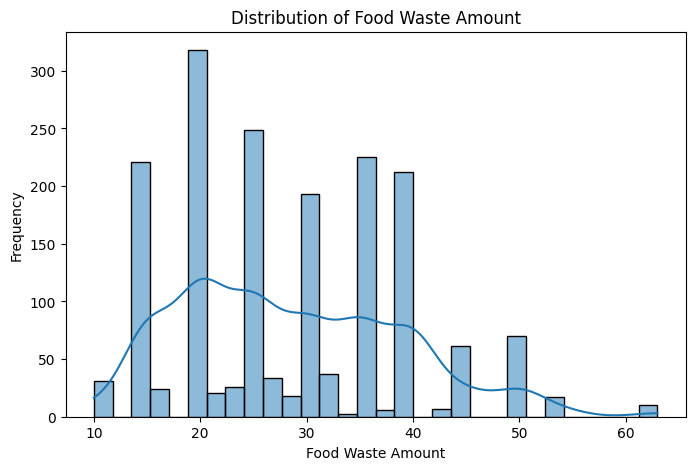

In [3]:
# Distribution of target variable

plt.figure(figsize=(8,5))
sns.histplot(df["Wastage Food Amount"], bins=30, kde=True)

plt.title("Distribution of Food Waste Amount")
plt.xlabel("Food Waste Amount")
plt.ylabel("Frequency")

plt.show()

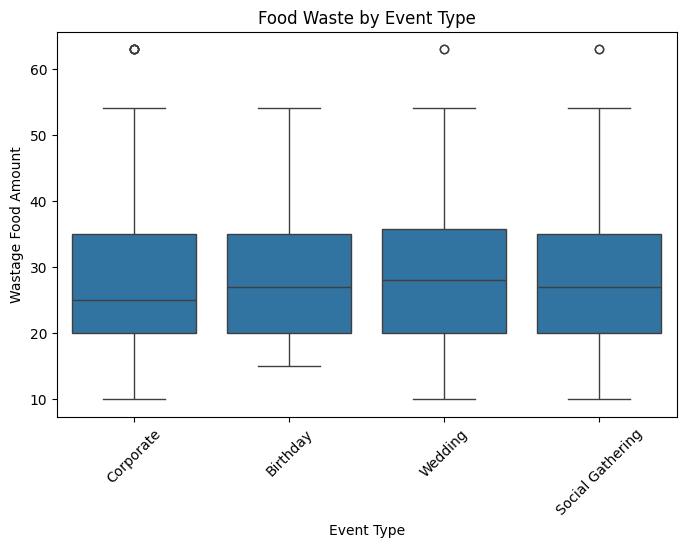

In [4]:
# Waste by Event Type

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Event Type",
    y="Wastage Food Amount",
    data=df
)

plt.xticks(rotation=45)

plt.title("Food Waste by Event Type")

plt.show()

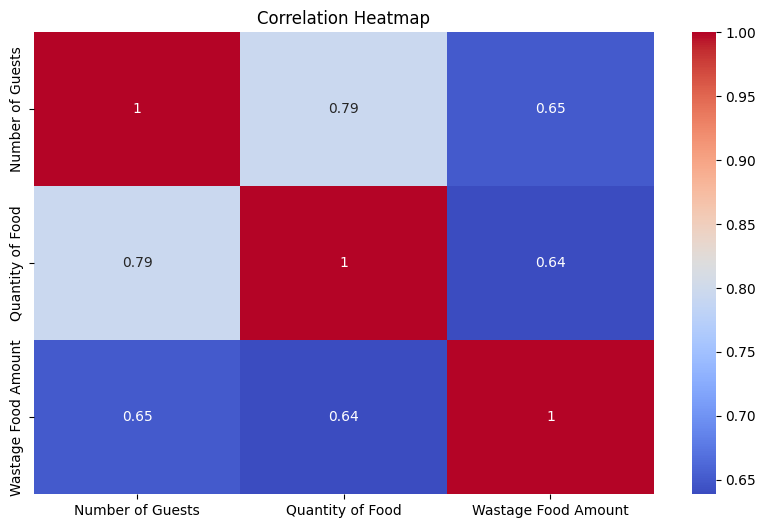

In [5]:
# Correlation Heatmap

numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# Business Insights

1. Food waste increases with the number of guests.
2. Quantity of food prepared strongly impacts wastage.
3. Weddings and social gatherings show higher variability in waste generation.
4. Predictive analytics can help restaurants reduce excess preparation and operational costs.

c:\Users\NAYANA NANI\anaconda3\envs\foodwaste\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\NAYANA NANI\anaconda3\envs\foodwaste\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator FunctionTransformer from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\NAYANA NANI\anaconda3\envs\foodwaste\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from v

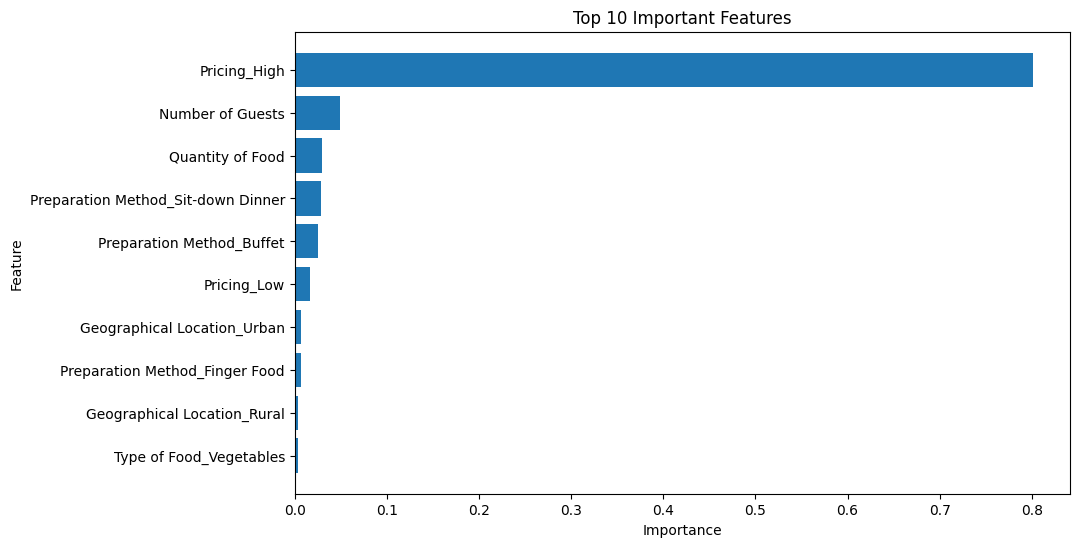

In [6]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

# Load model
model = joblib.load("../models/food_waste_model.pkl")

# Extract feature names
preprocessor = model.named_steps["preprocessor"]

encoded_features = preprocessor.named_transformers_["cat"]\
    .get_feature_names_out()

numeric_features = [
    col for col in df.columns
    if col not in [
        "Wastage Food Amount"
    ]
    and df[col].dtype != "object"
]

all_features = list(encoded_features) + numeric_features

# Feature importance
importance = model.named_steps["regressor"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": all_features,
    "Importance": importance
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Plot
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_df["Feature"][:10],
    feature_importance_df["Importance"][:10]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()